## Approximating eˣ with its Taylor Series

The exponential $e^x$ can't be computed by simple arithmetic on its own — but a
**Taylor series** rewrites it as a polynomial (a sum of $x$-power terms), which
*is* just arithmetic. This chart shows that polynomial getting better as we add
terms.

### The series

$$e^x \approx 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \dots$$

Each term is $\frac{x^k}{k!}$. Every derivative of $e^x$ equals $e^x$, and $e^0 = 1$,
so every coefficient on top is 1 — leaving just the factorials $1, 1, 2, 6, 24$
on the bottom.

### What the chart shows

The black curve is the true $e^x$. Each dashed line adds one more term, and each
one matches a further "feature" of the curve at $x = 0$:

- **1 term** ($1$): a flat line — matches only the **height** at 0.
- **2 terms** ($1 + x$): a tilted line — now matches the **slope**.
- **3 terms** ($1 + x + \frac{x^2}{2}$): a parabola — matches the **curvature**.
- **4–5 terms**: match finer bends, hugging the curve over a wider range.

### The key takeaway

The approximation is most accurate **near $x = 0$** (the point it's built around)
and drifts away from the true curve as $x$ grows — but **adding more terms** both
improves accuracy and widens the region where the polynomial stays glued to $e^x$.
This is exactly how calculators compute $e^x$: add enough terms until the error is
negligible.

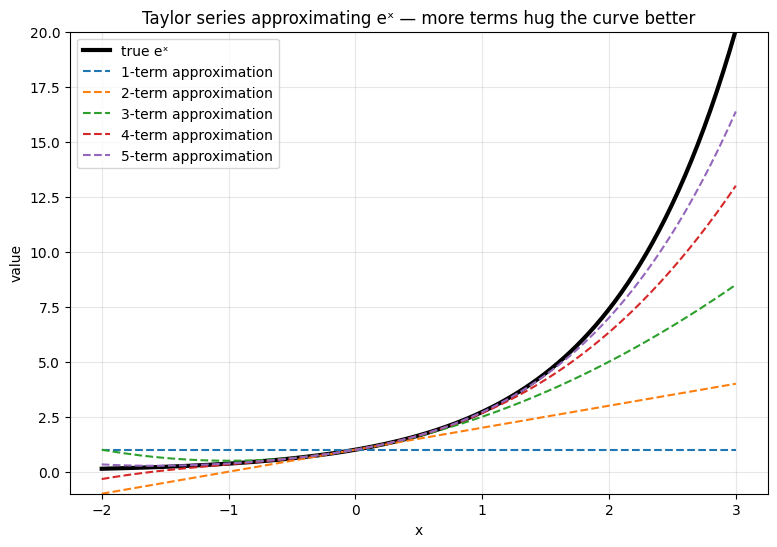

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# the true function
x = np.linspace(-2, 3, 200)
true = np.exp(x)

# Taylor approximation of e^x using the first n terms:
#   sum of x^k / k!  for k = 0 .. n-1
def taylor_exp(x, n_terms):
    result = np.zeros_like(x)
    for k in range(n_terms):
        result += x**k / math.factorial(k)   # the recipe: x^k / k!
    return result

plt.figure(figsize=(9, 6))
plt.plot(x, true, "k", lw=3, label="true eˣ")
for n in [1, 2, 3, 4, 5]:
    plt.plot(x, taylor_exp(x, n), "--", label=f"{n}-term approximation")

plt.ylim(-1, 20)
plt.title("Taylor series approximating eˣ — more terms hug the curve better")
plt.xlabel("x"); plt.ylabel("value")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Application of first and second derivatives in Bond duration and convexity 

Today's quant payoff, and it unifies the two topics of the day: **duration is a
first derivative, convexity is a second derivative** — and combining them to
predict price moves is a **Taylor series**.

### The setup
A bond's price $P$ depends on its yield $y$ (they move oppositely — yields up,
price down). So price is a function $P(y)$, and it traces a *curved*,
downward-sloping price–yield curve.

### The ladder of derivatives on that curve
- **Price** $P(y)$ — where you are (height of the curve).
- **Duration** $= \frac{dP}{dy}$ — the **slope**: how fast price changes as yield
  changes. (Here "duration" means this derivative, not a span of time.)
- **Convexity** $= \frac{d^2P}{dy^2}$ — the **curvature**: how fast the *slope
  (duration)* itself changes.

Each is the rate of change of the one above it.

### Putting them together (this is a Taylor series)
To estimate the price change for a yield move $\Delta y$:

$$\Delta P \approx \underbrace{\frac{dP}{dy}\,\Delta y}_{\text{duration term}}
+ \underbrace{\tfrac{1}{2}\frac{d^2P}{dy^2}(\Delta y)^2}_{\text{convexity term}}$$

This is exactly Taylor's recipe: a first-order (duration) term plus a
second-order (convexity) correction. For **small** yield moves, duration alone is
fine; for **large** moves the curve bends away from that straight-line estimate,
so the convexity term is needed — just like needing more Taylor terms far from the
center point.

### What the code shows
It builds a toy bond, computes duration and convexity **numerically** (the second
derivative uses $\frac{P(y+h) - 2P(y) + P(y-h)}{h^2}$), then predicts the price
change for a large (+1%) yield move — showing that **duration + convexity** beats
**duration alone**.

In [3]:

# a toy bond: price as a function of yield y
# (present value of annual coupons + face value, each discounted at yield y)
def bond_price(y, face=1000, coupon_rate=0.05, years=10):
    coupon = face * coupon_rate
    times = np.arange(1, years + 1)
    return np.sum(coupon / (1 + y)**times) + face / (1 + y)**years

y0 = 0.04                      # starting yield: 4%
h  = 1e-5

# duration  = first derivative dP/dy  (central difference)
dP  = (bond_price(y0 + h) - bond_price(y0 - h)) / (2*h)

# convexity = second derivative d2P/dy2
d2P = (bond_price(y0 + h) - 2*bond_price(y0) + bond_price(y0 - h)) / h**2

print(f"price at y = 4%:            {bond_price(y0):.2f}")
print(f"duration  (dP/dy):         {dP:.2f}")
print(f"convexity (d2P/dy2):       {d2P:.2f}")

# a LARGE yield move: +1% (4% -> 5%). Compare predictions to the true change.
dy = 0.01
actual              = bond_price(y0 + dy) - bond_price(y0)
pred_duration_only  = dP * dy                          # Taylor: 1st-order term
pred_with_convexity = dP * dy + 0.5 * d2P * dy**2      # + 2nd-order correction

print(f"\nfor a +1% yield move (4% -> 5%):")
print(f"  actual price change:        {actual:.2f}")
print(f"  duration only:              {pred_duration_only:.2f}   (off by {abs(actual - pred_duration_only):.2f})")
print(f"  duration + convexity:       {pred_with_convexity:.2f}   (off by {abs(actual - pred_with_convexity):.2f})")

price at y = 4%:            1081.11
duration  (dP/dy):         -8514.67
convexity (d2P/dy2):       83766.48

for a +1% yield move (4% -> 5%):
  actual price change:        -81.11
  duration only:              -85.15   (off by 4.04)
  duration + convexity:       -80.96   (off by 0.15)


## Self-check — Day 5 (Higher-order Derivatives & Taylor Series)

Answer each out loud before opening the answers.

**Q1.** What does the second derivative $f''$ tell you about a curve, and what do
$f'' > 0$ and $f'' < 0$ mean?

**Q2.** Find $f''$ and $f'''$ for $f(x) = 2x^3 + x^2$.

**Q3.** Write the Taylor recipe (first few terms) for a function around $x = 0$.
Why is there a factorial ($n!$) in each denominator?

**Q4.** Why does the Taylor series for $e^x$ have all 1's on top, giving
$1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \dots$?

**Q5.** A Taylor approximation is most accurate where, and how do you make it
accurate over a wider range?

**Q6.** In bonds: what is duration, and what is convexity, in terms of
derivatives of the price–yield curve?

**Q7.** The price-change estimate $\Delta P \approx \frac{dP}{dy}\Delta y +
\frac{1}{2}\frac{d^2P}{dy^2}(\Delta y)^2$ is an example of what? When is the
second (convexity) term actually needed?

---

<details>
<summary>Answers</summary>

**A1.** $f''$ is the rate of change of the slope — the **curvature**. $f'' > 0$:
curve bends upward (concave up, bowl). $f'' < 0$: bends downward (concave down,
dome).

**A2.** $f'(x) = 6x^2 + 2x$; $f''(x) = 12x + 2$; $f'''(x) = 12$.

**A3.** $f(x) \approx f(0) + f'(0)x + \frac{f''(0)}{2!}x^2 + \frac{f'''(0)}{3!}x^3 + \dots$
The $n!$ cancels the factor that appears when you differentiate $x^n$ a total of
$n$ times (e.g. $x^2$ differentiated twice gives $2 = 2!$), so each term
contributes exactly the right derivative.

**A4.** Because $e^x$ is its own derivative, so every derivative is $e^x$, and
$e^0 = 1$ — so every coefficient on top equals 1, leaving only the factorials
$1, 1, 2, 6, \dots$ underneath.

**A5.** Most accurate **near the point it's built around** (here $x = 0$); it
degrades farther away. Add **more terms** to both improve accuracy and widen the
region where it stays close.

**A6.** Duration $= \frac{dP}{dy}$ — the **first derivative** (slope of the
price-yield curve, i.e. price sensitivity). Convexity $= \frac{d^2P}{dy^2}$ — the
**second derivative** (curvature, i.e. how the slope/duration itself changes).

**A7.** A **Taylor series** (first-order duration term + second-order convexity
term). The convexity term is needed for **large** yield moves, where the curve
bends noticeably away from the straight-line (duration-only) estimate; for small
moves, duration alone is accurate enough.

</details>